In [1]:
# =============================================================================
# 셀 1: 06_TheForge_w_subr — 환경 + 설계
# =============================================================================
# 목적: 03_Sub_Regime의 확신도를 06_TheForge에 결합
#       Bull_High / Bull_Low 별도 가중치 최적화 → 성과 개선 여부 확인
#
# ─────────────────────────────────────────────────────────────────────
# [구조]
# ─────────────────────────────────────────────────────────────────────
#
#   06_TheForge(기존):
#     Bull    → {h=0.0, g1_bull=1.8, nsi=0.3}
#     Bear    → {h=0.7, a3=1.0, p5=0.7, e5=2.0, d1=0.7}
#     Neutral → {h=0.5, d3=1.1}
#
#   06_TheForge_w_subr(신규):
#     Bull_High → 공격적 가중치 (별도 최적화)
#     Bull_Low  → 보수적 가중치 (별도 최적화)
#     Bear      → 기존 유지
#     Neutral   → 기존 유지
#
# ─────────────────────────────────────────────────────────────────────
# [비교 계획]
# ─────────────────────────────────────────────────────────────────────
#
#   A) Baseline: 06_TheForge 2차 최적 (sub_regime 없음)
#   B) 실험군:   Bull_High/Low 별도 가중치
#   C) 판정:     B > A이면 채택, B ≤ A이면 폐기
#
# ─────────────────────────────────────────────────────────────────────
# [셀 구조 계획]
# ─────────────────────────────────────────────────────────────────────
#
#   셀 1: 설계 + 환경 (이 셀)
#   셀 2: 데이터 로드 (06 Cell 1~2 통합 + sub_regime 로드)
#   셀 3: Baseline 재현 (06 2차 최적 가중치 그대로)
#   셀 4: Bull_High / Bull_Low 별도 그리드서치
#   셀 5: 최종 비교 (A vs B)
#   셀 6: 저장 + 결론
#
# =============================================================================

import os, warnings, logging
from pathlib import Path
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from itertools import product
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
logger = logging.getLogger(__name__)

# ── SSOT 경로 ──
load_dotenv(Path("C:/QP2/.env"))
QP2_ROOT    = Path(os.getenv("QP2_ROOT", "C:/QP2"))
DATA_DIR    = QP2_ROOT / "data"
INTERIM_DIR = DATA_DIR / "interim"
META_DIR    = DATA_DIR / "meta"

# ── 파라미터 ──
TOP_N       = 30
COST_BP     = 20
AVOID_PENALTY = -2.0

# ── 06 기존 최적 가중치 (2차 세분화 결과) ──
BASELINE_WEIGHTS = {
    "Bull":    {"h_z": 0.0, "g1_bull_z": 1.8, "nsi_score": 0.3},
    "Bear":    {"h_z": 0.7, "a3_z": 1.0, "p5_z": 0.7, "e5_z": 2.0, "d1_z": 0.7},
    "Neutral": {"h_z": 0.5, "d3_z": 1.1},
}

# ── 공용 유틸 ──
def calc_perf(ret_series, name=""):
    cum = (1 + ret_series).cumprod()
    total = cum.iloc[-1]
    n_years = len(ret_series) / 12
    cagr = total ** (1 / n_years) - 1 if n_years > 0 else 0
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(12) if ret_series.std() > 0 else 0
    dd = cum / cum.cummax() - 1
    maxdd = dd.min()
    return {"name": name, "CAGR": cagr, "Sharpe": sharpe, "MaxDD": maxdd, "N": len(ret_series)}

def calc_tstat(port_ret, bm_ret):
    diff = port_ret - bm_ret
    n = len(diff.dropna())
    if n < 6 or diff.std() == 0:
        return 0.0
    return diff.mean() / diff.std() * np.sqrt(n)

# ── 차트 설정 ──
rcParams["figure.figsize"] = (14, 6)
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3

logger.info("셀 1 완료 — 06_TheForge_w_subr 환경 설정")
logger.info(f"  Baseline: {BASELINE_WEIGHTS}")

10:39:26 [INFO] 셀 1 완료 — 06_TheForge_w_subr 환경 설정
10:39:26 [INFO]   Baseline: {'Bull': {'h_z': 0.0, 'g1_bull_z': 1.8, 'nsi_score': 0.3}, 'Bear': {'h_z': 0.7, 'a3_z': 1.0, 'p5_z': 0.7, 'e5_z': 2.0, 'd1_z': 0.7}, 'Neutral': {'h_z': 0.5, 'd3_z': 1.1}}


In [3]:
# =============================================================================
# 셀 2: 데이터 로드 (06 Cell 1~2 통합 + sub_regime)
# =============================================================================
# 목적: 06_TheForge의 데이터 로드 + sub_regime.parquet 결합
# 산출물: panel, ret_1m, regime_map, sub_regime_map, t1_events, ticker_to_sector
# =============================================================================

SAVE_DIR = Path(r"C:\QP2\data\interim")

# ── 1. 팩터 시그널 로드 ──
h_sig    = pd.read_parquet(SAVE_DIR / "h_signal.parquet")
d_sig    = pd.read_parquet(SAVE_DIR / "d_signal.parquet")
a3_sig   = pd.read_parquet(SAVE_DIR / "a3_signal.parquet")
p5e5_sig = pd.read_parquet(SAVE_DIR / "p5_e5_signal.parquet")
g1_sig   = pd.read_parquet(SAVE_DIR / "g1_signal.parquet")
t1_events = pd.read_parquet(SAVE_DIR / "t1_events.parquet")
f_sig    = pd.read_parquet(SAVE_DIR / "fscore_signal.parquet")
p7_sig   = pd.read_parquet(SAVE_DIR / "p7_signal_panel.parquet")

# ── 2. 레짐 + sub_regime ──
regime_v4 = pd.read_parquet(SAVE_DIR / "regime_v4.parquet")

# date를 컬럼으로 확보 (인덱스든 컬럼이든)
if "date" not in regime_v4.columns:
    regime_v4 = regime_v4.reset_index()
    regime_v4.rename(columns={regime_v4.columns[0]: "date"}, inplace=True)
regime_v4["date"] = pd.to_datetime(regime_v4["date"])

regime_map = regime_v4.set_index("date")[["regime", "bear_phase"]].to_dict("index")

# sub_regime 로드
sub_regime = pd.read_parquet(SAVE_DIR / "sub_regime.parquet")
sub_regime.index = pd.to_datetime(sub_regime.index)
sub_regime_map = sub_regime["sub_regime_final"].to_dict()
logger.info(f"sub_regime 로드: {sub_regime.shape}")
logger.info(f"  분포:\n{sub_regime['sub_regime_final'].value_counts().sort_index().to_string()}")

# ── 3. 수익률 ──
ret_1m = pd.read_parquet(SAVE_DIR / "ret_1m_wide.parquet")
ret_1m.index = pd.to_datetime(ret_1m.index)

# ── 4. 유니버스 ──
universe = pd.read_parquet(Path(r"C:\QP2\data\meta") / "sp500_universe.parquet")
ticker_to_sector = universe.set_index("ticker_yahoo")["GICS Sector"].to_dict()

# ── 5. 패널 구성 (06 Cell 1 동일) ──
BT_START = "2013-06-30"
BT_END   = "2026-01-31"

panel = h_sig[["date", "ticker", "h_z"]].copy()
panel = panel.merge(d_sig[["date", "ticker", "d1_z", "d3_z"]], on=["date", "ticker"], how="left")
panel = panel.merge(a3_sig[["date", "ticker", "a3_z"]], on=["date", "ticker"], how="left")
panel = panel.merge(p5e5_sig[["date", "ticker", "p5_z", "e5_z"]], on=["date", "ticker"], how="left")
panel = panel.merge(g1_sig[["date", "ticker", "g1_bull_z", "g1_bear_z", "g1b_flag"]], 
                    on=["date", "ticker"], how="left")
panel = panel.merge(p7_sig, on=["date", "ticker"], how="left")
panel = panel.merge(f_sig, on=["date", "ticker"], how="left")

# 레짐 붙이기
regime_slim = regime_v4[["date", "regime", "bear_phase"]]
panel = panel.merge(regime_slim, on="date", how="left")

# 기간 필터
panel["date"] = pd.to_datetime(panel["date"])
panel = panel[(panel["date"] >= BT_START) & (panel["date"] <= BT_END)]

# sub_regime 붙이기
panel["sub_regime"] = panel["date"].map(sub_regime_map)

logger.info(f"패널: {panel.shape}")
logger.info(f"  기간: {panel['date'].min()} ~ {panel['date'].max()}")
logger.info(f"  고유 날짜: {panel['date'].nunique()}")
logger.info(f"  sub_regime 분포:\n{panel.groupby('date')['sub_regime'].first().value_counts().sort_index().to_string()}")

# ── 6. 06 함수 정의 (backtest_single_regime, backtest_weighted) ──
def backtest_single_regime(panel_df, ret_1m_df, target_regime, weights_dict,
                           t1_events_df=None, ticker_to_sector_dict=None,
                           top_n=30, cost_bp=20, avoid_penalty=-2.0,
                           t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20,
                           sub_regime_col=None):
    """sub_regime_col이 주어지면 해당 컬럼으로 레짐 필터링"""
    if sub_regime_col:
        regime_dates = panel_df[panel_df[sub_regime_col] == target_regime]["date"].unique()
    else:
        regime_dates = panel_df[panel_df["regime"] == target_regime]["date"].unique()
    
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        if dt not in regime_dates:
            prev_holdings = set()
            continue
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        
        factor_cols = [col for col in weights_dict.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        
        weight_arr = np.array([weights_dict[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        
        # G-1b 회피 (Bear/Neutral)
        orig_regime = month_data["regime"].iloc[0] if len(month_data) > 0 else ""
        if orig_regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        
        # F-1 필터 (Bear)
        if orig_regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        
        # T-1 이벤트 (Bull)
        if orig_regime == "Bull" and t1_events_df is not None and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0 and ticker_to_sector_dict:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        
        valid = month_data.dropna(subset=["composite_z"])
        if len(valid) < 10:
            continue
        top_n_actual = min(top_n, len(valid))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"port_ret": port_ret - cost, "bm_ret": bm_ret})
        prev_holdings = curr_set
    
    if not results:
        return {"sharpe": -999, "cagr": 0, "months": 0, "excess": 0}
    df = pd.DataFrame(results)
    excess = df["port_ret"] - df["bm_ret"]
    port_ann = df["port_ret"].mean() * 12
    port_vol = df["port_ret"].std() * np.sqrt(12)
    sharpe = port_ann / port_vol if port_vol > 0 else 0
    bm_ann = df["bm_ret"].mean() * 12
    bm_vol = df["bm_ret"].std() * np.sqrt(12)
    bm_sharpe = bm_ann / bm_vol if bm_vol > 0 else 0
    excess_ann = excess.mean() * 12
    t_stat = excess.mean() / (excess.std() / np.sqrt(len(excess))) if excess.std() > 0 else 0
    return {"sharpe": sharpe, "bm_sharpe": bm_sharpe, "cagr": port_ann, "bm_cagr": bm_ann,
            "excess": excess_ann, "tstat": t_stat, "months": len(df)}


def backtest_weighted_subr(panel_df, ret_1m_df, regime_map_dict, sub_regime_map_dict,
                           weight_set, t1_events_df, ticker_to_sector_dict,
                           top_n=30, cost_bp=20, avoid_penalty=-2.0,
                           t1_bonus=1.0, t1_lookback=7, f1_cutoff=0.20):
    """backtest_weighted 확장 — sub_regime별 가중치 적용"""
    all_dates = sorted(panel_df["date"].unique())
    results = []
    prev_holdings = set()
    
    for i, dt in enumerate(all_dates[:-1]):
        next_dt = all_dates[i + 1]
        regime_info = regime_map_dict.get(dt, None)
        if regime_info is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            regime_info = regime_map_dict.get(dt_me, None)
        if regime_info is None:
            continue
        
        regime = regime_info["regime"]
        bear_phase = regime_info.get("bear_phase", "")
        
        # sub_regime 결정
        sub_reg = sub_regime_map_dict.get(dt, None)
        if sub_reg is None:
            dt_me = pd.Timestamp(dt) + pd.offsets.MonthEnd(0)
            sub_reg = sub_regime_map_dict.get(dt_me, None)
        if sub_reg is None:
            sub_reg = regime  # fallback
        
        # sub_regime에 맞는 가중치 선택
        weights = weight_set.get(sub_reg, weight_set.get(regime, {}))
        if not weights:
            continue
        
        month_data = panel_df[panel_df["date"] == dt].copy()
        if len(month_data) < top_n:
            continue
        
        factor_cols = [col for col in weights.keys() if col in month_data.columns]
        if not factor_cols:
            continue
        
        weight_arr = np.array([weights[col] for col in factor_cols])
        values_df = month_data[factor_cols].copy()
        valid_mask = values_df.notna().values
        weighted_vals = np.where(valid_mask, values_df.values * weight_arr, 0)
        active_weights = np.where(valid_mask, weight_arr, 0)
        sum_w = active_weights.sum(axis=1)
        sum_w[sum_w == 0] = np.nan
        month_data["composite_z"] = weighted_vals.sum(axis=1) / sum_w
        
        if regime in ["Bear", "Neutral"]:
            mask_avoid = month_data["g1b_flag"] == 1
            month_data.loc[mask_avoid, "composite_z"] += avoid_penalty
        if regime == "Bear":
            fscore_valid = month_data["fscore"].dropna()
            if len(fscore_valid) > 0:
                cutoff = fscore_valid.quantile(f1_cutoff)
                month_data.loc[month_data["fscore"] < cutoff, "composite_z"] = np.nan
        if regime == "Bull" and len(t1_events_df) > 0:
            dt_ts = pd.Timestamp(dt)
            recent = t1_events_df[
                (t1_events_df["date"] >= dt_ts - pd.Timedelta(days=t1_lookback)) &
                (t1_events_df["date"] <= dt_ts)
            ]
            if len(recent) > 0:
                event_sectors = set(recent["sector"].unique())
                for idx_row in month_data.index:
                    tk = month_data.loc[idx_row, "ticker"]
                    sector = ticker_to_sector_dict.get(tk, "")
                    if sector in event_sectors:
                        month_data.loc[idx_row, "composite_z"] += t1_bonus
        
        valid = month_data.dropna(subset=["composite_z"])
        top_n_actual = min(top_n, max(10, len(valid)))
        top = valid.nlargest(top_n_actual, "composite_z")
        selected = top["ticker"].tolist()
        
        if next_dt not in ret_1m_df.index:
            continue
        available = [t for t in selected if t in ret_1m_df.columns]
        if not available:
            continue
        rets = ret_1m_df.loc[next_dt, available].dropna()
        if len(rets) == 0:
            continue
        
        port_ret = rets.mean()
        bm_ret = ret_1m_df.loc[next_dt].dropna().mean()
        curr_set = set(selected)
        turnover = len(curr_set - prev_holdings) / len(curr_set) if prev_holdings else 1.0
        cost = turnover * cost_bp * 2 / 10000
        results.append({"date": next_dt, "regime": regime, "sub_regime": sub_reg,
                        "bear_phase": bear_phase,
                        "port_ret_net": port_ret - cost, "bm_ret": bm_ret, "turnover": turnover})
        prev_holdings = curr_set
    
    df = pd.DataFrame(results)
    if len(df) == 0:
        return df
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["excess_net"] = df["port_ret_net"] - df["bm_ret"]
    df["cum_port"] = (1 + df["port_ret_net"]).cumprod()
    df["cum_bm"] = (1 + df["bm_ret"]).cumprod()
    return df

logger.info("셀 2 완료 — 데이터 + 함수 로드")

10:41:48 [INFO] sub_regime 로드: (153, 12)
10:41:48 [INFO]   분포:
sub_regime_final
Bear         23
Bull_High    28
Bull_Low     89
Neutral      13
10:41:49 [INFO] 패널: (76456, 26)
10:41:49 [INFO]   기간: 2013-06-30 00:00:00 ~ 2026-01-31 00:00:00
10:41:49 [INFO]   고유 날짜: 152
10:41:49 [INFO]   sub_regime 분포:
sub_regime
Bear         23
Bull_High    28
Bull_Low     88
Neutral      13
10:41:49 [INFO] 셀 2 완료 — 데이터 + 함수 로드


In [5]:
# =============================================================================
# 셀 3: Baseline 고정 + Sub-Regime 조정 계수 탐색
# =============================================================================
# 목적:
#   기존 06 최적 가중치(composite_z)를 고정하고
#   Bull_High / Bull_Low에서 조정 계수만 탐색
#
# 전략:
#   Bull_High: 기존 가중치 그대로 (이미 공격적) → 부스트 필요한가?
#   Bull_Low:  기존 가중치 × scale + 방어점수 × defense_w
#   Bear/Neutral: 기존 유지
# =============================================================================

# ── 1. Baseline 재현 ──
bt_baseline = backtest_weighted_subr(
    panel, ret_1m, regime_map, sub_regime_map,
    weight_set={
        "Bull_High": BASELINE_WEIGHTS["Bull"],
        "Bull_Low":  BASELINE_WEIGHTS["Bull"],
        "Bear":      BASELINE_WEIGHTS["Bear"],
        "Neutral":   BASELINE_WEIGHTS["Neutral"],
    },
    t1_events_df=t1_events, ticker_to_sector_dict=ticker_to_sector,
    top_n=TOP_N, cost_bp=COST_BP,
)

bl_perf = calc_perf(bt_baseline["port_ret_net"], "Baseline")
bl_t = calc_tstat(bt_baseline["port_ret_net"], bt_baseline["bm_ret"])

print("=" * 70)
print("Baseline (sub_regime 미분할, 동일 가중치)")
print("=" * 70)
print(f"  CAGR={bl_perf['CAGR']:.2%}, Sharpe={bl_perf['Sharpe']:.2f}, "
      f"MaxDD={bl_perf['MaxDD']:.2%}, t={bl_t:.2f}")

# ── 2. Bull_High: 기존 vs 약간 공격적 ──
# 기존이 이미 g1_bull=1.8로 공격적이니까, 부스트 효과만 확인
print("\n" + "=" * 70)
print("Bull_High 가중치 탐색 (기존 구조 유지, 스케일만)")
print("=" * 70)

high_results = []
# g1_bull 비중만 미세 조정 (기존 1.8 근처)
for g1w in [1.0, 1.5, 1.8, 2.0, 2.5, 3.0]:
    for nsi_w in [0.0, 0.3, 0.5, 1.0]:
        w = {"h_z": 0.0, "g1_bull_z": g1w, "nsi_score": nsi_w}
        res = backtest_single_regime(
            panel, ret_1m, "Bull_High", w,
            t1_events_df=t1_events, ticker_to_sector_dict=ticker_to_sector,
            top_n=TOP_N, cost_bp=COST_BP, sub_regime_col="sub_regime"
        )
        high_results.append({**res, "g1": g1w, "nsi": nsi_w})

hr_df = pd.DataFrame(high_results).sort_values("sharpe", ascending=False)
print(hr_df[["g1", "nsi", "sharpe", "cagr", "excess", "tstat", "months"]].head(10).to_string(index=False))
best_high_w = {"h_z": 0.0, "g1_bull_z": hr_df.iloc[0]["g1"], "nsi_score": hr_df.iloc[0]["nsi"]}
print(f"\n  ★ Bull_High 최적: {best_high_w}, Sharpe={hr_df.iloc[0]['sharpe']:.3f}")

# ── 3. Bull_Low: 기존 Bull 가중치 + 방어 팩터 혼합 ──
# 핵심 질문: Low confidence Bull에서 방어 섞으면 나아지나?
print("\n" + "=" * 70)
print("Bull_Low 가중치 탐색 (Bull 기본 + 방어 혼합)")
print("=" * 70)

low_results = []
for g1w in [0.5, 1.0, 1.5, 1.8, 2.0]:
    for nsi_w in [0.0, 0.3, 0.5]:
        for p5w in [0.0, 0.3, 0.5, 1.0]:
            for e5w in [0.0, 0.3, 0.5, 1.0]:
                w = {"h_z": 0.0, "g1_bull_z": g1w, "nsi_score": nsi_w,
                     "p5_z": p5w, "e5_z": e5w}
                res = backtest_single_regime(
                    panel, ret_1m, "Bull_Low", w,
                    t1_events_df=t1_events, ticker_to_sector_dict=ticker_to_sector,
                    top_n=TOP_N, cost_bp=COST_BP, sub_regime_col="sub_regime"
                )
                low_results.append({**res, "g1": g1w, "nsi": nsi_w, "p5": p5w, "e5": e5w})

lr_df = pd.DataFrame(low_results).sort_values("sharpe", ascending=False)
print(lr_df[["g1", "nsi", "p5", "e5", "sharpe", "cagr", "excess", "tstat", "months"]].head(10).to_string(index=False))
best_low_w = {"h_z": 0.0, "g1_bull_z": lr_df.iloc[0]["g1"], "nsi_score": lr_df.iloc[0]["nsi"],
              "p5_z": lr_df.iloc[0]["p5"], "e5_z": lr_df.iloc[0]["e5"]}
print(f"\n  ★ Bull_Low 최적: {best_low_w}, Sharpe={lr_df.iloc[0]['sharpe']:.3f}")

# ── 4. 비교 요약 ──
print("\n" + "=" * 70)
print("가중치 비교")
print("=" * 70)
print(f"  Baseline Bull:  {BASELINE_WEIGHTS['Bull']}")
print(f"  Bull_High:      {best_high_w}")
print(f"  Bull_Low:       {best_low_w}")

logger.info(f"셀 3 완료")
logger.info(f"  Bull_High 탐색: {len(high_results)}개 ({hr_df.iloc[0]['months']}M)")
logger.info(f"  Bull_Low 탐색:  {len(low_results)}개 ({lr_df.iloc[0]['months']}M)")

Baseline (sub_regime 미분할, 동일 가중치)
  CAGR=17.59%, Sharpe=0.98, MaxDD=-16.87%, t=0.85

Bull_High 가중치 탐색 (기존 구조 유지, 스케일만)
 g1  nsi   sharpe     cagr    excess     tstat  months
1.5  1.0 0.302057 0.046310 -0.013142 -0.203438      28
1.8  1.0 0.272867 0.042480 -0.016972 -0.251146      28
2.0  0.3 0.269875 0.039571 -0.019882 -0.319480      28
1.0  0.5 0.256637 0.038955 -0.020497 -0.313652      28
2.0  1.0 0.256637 0.038955 -0.020497 -0.313652      28
3.0  0.3 0.251099 0.036788 -0.022665 -0.360089      28
1.0  1.0 0.248561 0.036430 -0.023023 -0.362626      28
2.0  0.5 0.247821 0.034987 -0.024465 -0.415940      28
2.5  1.0 0.241275 0.034808 -0.024644 -0.399712      28
1.5  0.3 0.235764 0.033317 -0.026135 -0.440250      28

  ★ Bull_High 최적: {'h_z': 0.0, 'g1_bull_z': np.float64(1.5), 'nsi_score': np.float64(1.0)}, Sharpe=0.302

Bull_Low 가중치 탐색 (Bull 기본 + 방어 혼합)


11:04:15 [INFO] 셀 3 완료
11:04:15 [INFO]   Bull_High 탐색: 24개 (28.0M)
11:04:15 [INFO]   Bull_Low 탐색:  240개 (87.0M)


 g1  nsi  p5  e5   sharpe     cagr    excess     tstat  months
1.8  0.3 0.0 0.0 0.989799 0.195683  0.044707  0.935361      87
2.0  0.3 0.0 0.0 0.981231 0.186953  0.035977  0.800123      87
1.8  0.3 0.0 0.5 0.978143 0.158283  0.007306  0.211789      87
1.8  0.5 0.0 0.5 0.974981 0.153035  0.002058  0.063877      87
1.5  0.3 1.0 0.3 0.961908 0.124321 -0.026655 -0.795061      87
1.5  0.3 0.0 0.0 0.960380 0.190269  0.039293  0.823610      87
1.8  0.5 0.5 0.3 0.957675 0.134978 -0.015998 -0.488883      87
1.5  0.5 1.0 0.3 0.954754 0.124814 -0.026162 -0.785518      87
2.0  0.5 0.0 0.0 0.948812 0.185582  0.034606  0.740361      87
0.5  0.5 1.0 0.3 0.939928 0.109725 -0.041252 -1.115622      87

  ★ Bull_Low 최적: {'h_z': 0.0, 'g1_bull_z': np.float64(1.8), 'nsi_score': np.float64(0.3), 'p5_z': np.float64(0.0), 'e5_z': np.float64(0.0)}, Sharpe=0.990

가중치 비교
  Baseline Bull:  {'h_z': 0.0, 'g1_bull_z': 1.8, 'nsi_score': 0.3}
  Bull_High:      {'h_z': 0.0, 'g1_bull_z': np.float64(1.5), 'nsi_score': np.

자산배분 그리드 탐색

Top 15 조합:
 cash_low  cash_bear   CAGR  Sharpe   MaxDD       t
   0.1500     0.0000 0.1595  0.9890 -0.1598  0.3805
   0.2000     0.0000 0.1540  0.9890 -0.1569  0.1910
   0.1000     0.0000 0.1650  0.9882 -0.1627  0.5538
   0.2500     0.0000 0.1484  0.9879 -0.1541 -0.0146
   0.0500     0.0000 0.1705  0.9867 -0.1657  0.7112
   0.3000     0.0000 0.1428  0.9855 -0.1513 -0.2348
   0.0000     0.0000 0.1759  0.9846 -0.1687  0.8535
   0.2000     0.1000 0.1502  0.9846 -0.1494  0.0527
   0.2500     0.1000 0.1446  0.9842 -0.1465 -0.1541
   0.1500     0.1000 0.1557  0.9840 -0.1523  0.2446
   0.1000     0.1000 0.1612  0.9827 -0.1553  0.4209
   0.3000     0.1000 0.1391  0.9825 -0.1437 -0.3747
   0.0500     0.1000 0.1666  0.9807 -0.1583  0.5818
   0.2500     0.2000 0.1408  0.9783 -0.1390 -0.2871
   0.0000     0.1000 0.1721  0.9782 -0.1613  0.7281

Baseline (현금 0%): Sharpe=0.9846, CAGR=0.1759, MaxDD=-0.1687
Best:               Sharpe=0.9890, CAGR=0.1595, MaxDD=-0.1598
  → Sharpe 개선: +0.004

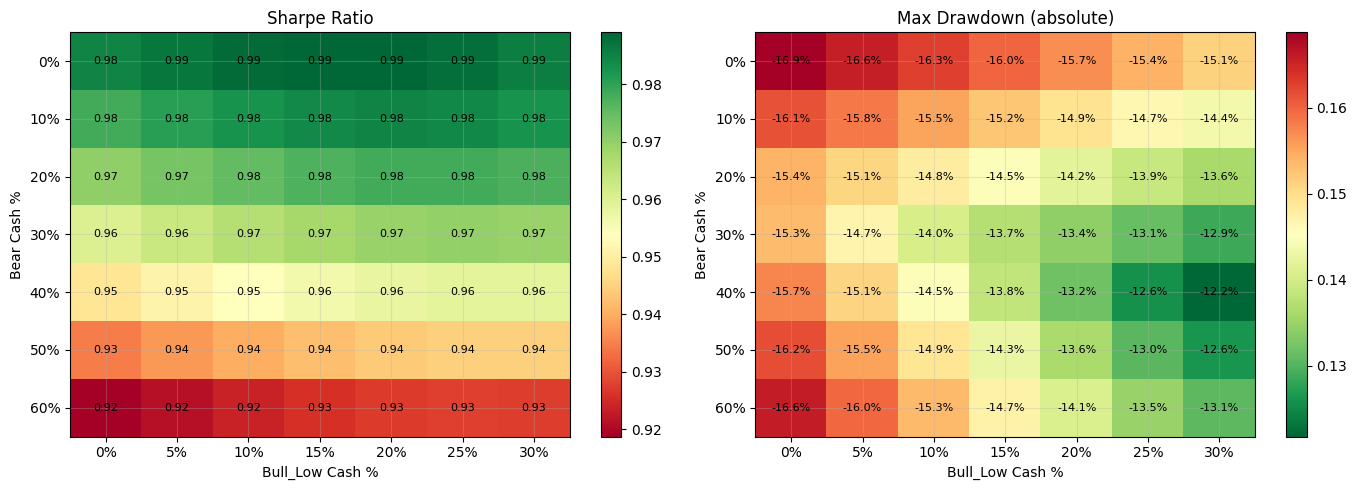

11:07:38 [INFO] 셀 4 완료 — 자산배분 그리드 탐색


In [6]:
# =============================================================================
# 셀 4: 자산배분 레이어 — confidence 기반 현금 비중
# =============================================================================
# 목적: sub_regime별 주식/현금 비중 조절 → MDD 개선 여부 확인
#       팩터 가중치는 기존 06 최적 그대로 고정
#
# 전략:
#   Bull_High → 주식 100%
#   Bull_Low  → 주식 × (1 - cash_low)
#   Bear      → 주식 × (1 - cash_bear)
#   Neutral   → 주식 100%
#
# 현금 수익률 = 0% (보수적 가정)
# =============================================================================

# ── 1. bt_baseline 결과에 현금 비중 적용하는 함수 ──
def apply_cash_allocation(bt_df, sub_regime_map_dict, cash_map):
    """
    bt_df: backtest_weighted_subr 결과 (port_ret_net, bm_ret, sub_regime 컬럼)
    cash_map: {"Bull_High": 0.0, "Bull_Low": 0.1, "Bear": 0.5, "Neutral": 0.0}
    현금 수익률 = 0%
    """
    df = bt_df.copy()
    df["cash_pct"] = df["sub_regime"].map(cash_map).fillna(0)
    df["port_ret_adj"] = df["port_ret_net"] * (1 - df["cash_pct"])
    df["cum_port_adj"] = (1 + df["port_ret_adj"]).cumprod()
    return df

# ── 2. 그리드 탐색 ──
# Bull_High: 항상 100% 주식 (고정)
# Neutral: 항상 100% 주식 (고정, 표본 적음)
# 탐색 대상: Bull_Low 현금비중, Bear 현금비중

print("=" * 70)
print("자산배분 그리드 탐색")
print("=" * 70)

cash_results = []
for cash_low in [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    for cash_bear in [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]:
        cash_map = {
            "Bull_High": 0.0,
            "Bull_Low": cash_low,
            "Bear": cash_bear,
            "Neutral": 0.0,
        }
        df = apply_cash_allocation(bt_baseline, sub_regime_map, cash_map)
        
        perf = calc_perf(df["port_ret_adj"], "adj")
        t = calc_tstat(df["port_ret_adj"], df["bm_ret"])
        
        cash_results.append({
            "cash_low": cash_low,
            "cash_bear": cash_bear,
            "CAGR": perf["CAGR"],
            "Sharpe": perf["Sharpe"],
            "MaxDD": perf["MaxDD"],
            "t": t,
        })

cr_df = pd.DataFrame(cash_results).sort_values("Sharpe", ascending=False)

print("\nTop 15 조합:")
print(cr_df.head(15).to_string(index=False, float_format="%.4f"))

# Baseline (현금 0%) 위치 확인
bl_row = cr_df[(cr_df["cash_low"] == 0) & (cr_df["cash_bear"] == 0)].iloc[0]
print(f"\nBaseline (현금 0%): Sharpe={bl_row['Sharpe']:.4f}, CAGR={bl_row['CAGR']:.4f}, MaxDD={bl_row['MaxDD']:.4f}")
print(f"Best:               Sharpe={cr_df.iloc[0]['Sharpe']:.4f}, CAGR={cr_df.iloc[0]['CAGR']:.4f}, MaxDD={cr_df.iloc[0]['MaxDD']:.4f}")
print(f"  → Sharpe 개선: {cr_df.iloc[0]['Sharpe'] - bl_row['Sharpe']:+.4f}")
print(f"  → MaxDD 개선:  {cr_df.iloc[0]['MaxDD'] - bl_row['MaxDD']:+.4f}")

# ── 3. 히트맵 시각화 ──
pivot_sharpe = cr_df.pivot_table(index="cash_bear", columns="cash_low", values="Sharpe")
pivot_mdd = cr_df.pivot_table(index="cash_bear", columns="cash_low", values="MaxDD")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(pivot_sharpe.values, cmap="RdYlGn", aspect="auto")
axes[0].set_xticks(range(len(pivot_sharpe.columns)))
axes[0].set_xticklabels([f"{x:.0%}" for x in pivot_sharpe.columns])
axes[0].set_yticks(range(len(pivot_sharpe.index)))
axes[0].set_yticklabels([f"{x:.0%}" for x in pivot_sharpe.index])
axes[0].set_xlabel("Bull_Low Cash %")
axes[0].set_ylabel("Bear Cash %")
axes[0].set_title("Sharpe Ratio")
for i in range(len(pivot_sharpe.index)):
    for j in range(len(pivot_sharpe.columns)):
        axes[0].text(j, i, f"{pivot_sharpe.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pivot_mdd.values * -1, cmap="RdYlGn_r", aspect="auto")
axes[1].set_xticks(range(len(pivot_mdd.columns)))
axes[1].set_xticklabels([f"{x:.0%}" for x in pivot_mdd.columns])
axes[1].set_yticks(range(len(pivot_mdd.index)))
axes[1].set_yticklabels([f"{x:.0%}" for x in pivot_mdd.index])
axes[1].set_xlabel("Bull_Low Cash %")
axes[1].set_ylabel("Bear Cash %")
axes[1].set_title("Max Drawdown (absolute)")
for i in range(len(pivot_mdd.index)):
    for j in range(len(pivot_mdd.columns)):
        axes[1].text(j, i, f"{pivot_mdd.values[i,j]:.1%}", ha="center", va="center", fontsize=8)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

logger.info("셀 4 완료 — 자산배분 그리드 탐색")

In [7]:
# =============================================================================
# 셀 5-1: Bear_High만 현금 — 빠른 확인
# =============================================================================

print("=" * 70)
print("Bear_High만 현금, Bear_Low는 주식 유지")
print("=" * 70)

# Bear_High / Bear_Low 구분을 위해 sub_regime 세분화
# 기존 sub_regime_map에서 Bear는 단일인데, confidence로 나눠야 함
sub_reg_detail = sub_regime.copy()
bear_mask = sub_reg_detail["sub_regime_final"] == "Bear"
sub_reg_detail.loc[bear_mask, "sub_regime_detail"] = sub_reg_detail.loc[bear_mask, "sub_regime"]
sub_reg_detail.loc[~bear_mask, "sub_regime_detail"] = sub_reg_detail.loc[~bear_mask, "sub_regime_final"]
sub_detail_map = sub_reg_detail["sub_regime_detail"].to_dict()

# Bear_High/Low 분포 확인
print("Bear 세분화:")
print(sub_reg_detail[bear_mask]["sub_regime_detail"].value_counts().to_string())

# 현금 비중 테스트
bear_hi_results = []
for cash_bear_hi in [0.0, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    df = bt_baseline.copy()
    # sub_regime_detail 매핑
    df["sub_detail"] = df.index.map(sub_detail_map)
    
    cash_pct = pd.Series(0.0, index=df.index)
    cash_pct[df["sub_detail"] == "Bear_High"] = cash_bear_hi
    # Bull_Low는 아까 best=15%였으니 같이 넣어봄
    cash_pct[df["sub_detail"] == "Bull_Low"] = 0.15
    
    df["port_ret_adj"] = df["port_ret_net"] * (1 - cash_pct)
    
    perf = calc_perf(df["port_ret_adj"])
    t = calc_tstat(df["port_ret_adj"], df["bm_ret"])
    
    bear_hi_results.append({
        "cash_bear_hi": cash_bear_hi,
        "CAGR": perf["CAGR"],
        "Sharpe": perf["Sharpe"],
        "MaxDD": perf["MaxDD"],
        "t": t,
    })

bh_df = pd.DataFrame(bear_hi_results)
print("\nBear_High 현금비중별 성과 (Bull_Low=15% 고정):")
print(bh_df.to_string(index=False, float_format="%.4f"))

# Baseline 비교
print(f"\nBaseline (현금 0%):     Sharpe={0.9846:.4f}, MaxDD={-0.1687:.4f}")
print(f"Best Bear_High 현금:    Sharpe={bh_df.loc[bh_df['Sharpe'].idxmax(), 'Sharpe']:.4f}, "
      f"MaxDD={bh_df.loc[bh_df['Sharpe'].idxmax(), 'MaxDD']:.4f}, "
      f"cash={bh_df.loc[bh_df['Sharpe'].idxmax(), 'cash_bear_hi']:.0%}")

Bear_High만 현금, Bear_Low는 주식 유지
Bear 세분화:
sub_regime_detail
Bear_Low     16
Bear_High     7

Bear_High 현금비중별 성과 (Bull_Low=15% 고정):
 cash_bear_hi   CAGR  Sharpe   MaxDD      t
       0.0000 0.1550  0.9579 -0.1761 0.2478
       0.2000 0.1566  0.9779 -0.1486 0.2757
       0.3000 0.1573  0.9870 -0.1347 0.2884
       0.4000 0.1580  0.9955 -0.1266 0.3004
       0.5000 0.1587  1.0032 -0.1266 0.3117
       0.6000 0.1594  1.0103 -0.1266 0.3221
       0.7000 0.1600  1.0165 -0.1266 0.3317
       0.8000 0.1607  1.0220 -0.1266 0.3406

Baseline (현금 0%):     Sharpe=0.9846, MaxDD=-0.1687
Best Bear_High 현금:    Sharpe=1.0220, MaxDD=-0.1266, cash=80%


In [8]:
# =============================================================================
# 셀 5-1: Bear_High만 현금 — 빠른 확인
# =============================================================================

print("=" * 70)
print("Bear_High만 현금, Bear_Low는 주식 유지")
print("=" * 70)

# Bear_High / Bear_Low 구분을 위해 sub_regime 세분화
# 기존 sub_regime_map에서 Bear는 단일인데, confidence로 나눠야 함
sub_reg_detail = sub_regime.copy()
bear_mask = sub_reg_detail["sub_regime_final"] == "Bear"
sub_reg_detail.loc[bear_mask, "sub_regime_detail"] = sub_reg_detail.loc[bear_mask, "sub_regime"]
sub_reg_detail.loc[~bear_mask, "sub_regime_detail"] = sub_reg_detail.loc[~bear_mask, "sub_regime_final"]
sub_detail_map = sub_reg_detail["sub_regime_detail"].to_dict()

# Bear_High/Low 분포 확인
print("Bear 세분화:")
print(sub_reg_detail[bear_mask]["sub_regime_detail"].value_counts().to_string())

# 현금 비중 테스트
bear_hi_results = []
for cash_bear_hi in [0.0, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    df = bt_baseline.copy()
    # sub_regime_detail 매핑
    df["sub_detail"] = df.index.map(sub_detail_map)
    
    cash_pct = pd.Series(0.0, index=df.index)
    cash_pct[df["sub_detail"] == "Bear_High"] = cash_bear_hi
    # Bull_Low는 아까 best=15%였으니 같이 넣어봄
    cash_pct[df["sub_detail"] == "Bull_Low"] = 0.15
    
    df["port_ret_adj"] = df["port_ret_net"] * (1 - cash_pct)
    
    perf = calc_perf(df["port_ret_adj"])
    t = calc_tstat(df["port_ret_adj"], df["bm_ret"])
    
    bear_hi_results.append({
        "cash_bear_hi": cash_bear_hi,
        "CAGR": perf["CAGR"],
        "Sharpe": perf["Sharpe"],
        "MaxDD": perf["MaxDD"],
        "t": t,
    })

bh_df = pd.DataFrame(bear_hi_results)
print("\nBear_High 현금비중별 성과 (Bull_Low=15% 고정):")
print(bh_df.to_string(index=False, float_format="%.4f"))

# Baseline 비교
print(f"\nBaseline (현금 0%):     Sharpe={0.9846:.4f}, MaxDD={-0.1687:.4f}")
print(f"Best Bear_High 현금:    Sharpe={bh_df.loc[bh_df['Sharpe'].idxmax(), 'Sharpe']:.4f}, "
      f"MaxDD={bh_df.loc[bh_df['Sharpe'].idxmax(), 'MaxDD']:.4f}, "
      f"cash={bh_df.loc[bh_df['Sharpe'].idxmax(), 'cash_bear_hi']:.0%}")

      #   C. Bear_High만 현금 (셀 5-1)
#      - Bear_High(7M)만 현금, Bear_Low(16M)는 주식 유지
#      - Best: cash_bear_hi=80%, Sharpe=1.02, MaxDD=-12.66%
#      - Baseline 대비: Sharpe +0.04, MaxDD +4.2%p
#      - 판정: 7개월 표본으로 80% 현금 = 과적합. 폐기.
#      - 단, 향후 Bear 표본 축적 시 재검증 가치 있음

Bear_High만 현금, Bear_Low는 주식 유지
Bear 세분화:
sub_regime_detail
Bear_Low     16
Bear_High     7

Bear_High 현금비중별 성과 (Bull_Low=15% 고정):
 cash_bear_hi   CAGR  Sharpe   MaxDD      t
       0.0000 0.1550  0.9579 -0.1761 0.2478
       0.2000 0.1566  0.9779 -0.1486 0.2757
       0.3000 0.1573  0.9870 -0.1347 0.2884
       0.4000 0.1580  0.9955 -0.1266 0.3004
       0.5000 0.1587  1.0032 -0.1266 0.3117
       0.6000 0.1594  1.0103 -0.1266 0.3221
       0.7000 0.1600  1.0165 -0.1266 0.3317
       0.8000 0.1607  1.0220 -0.1266 0.3406

Baseline (현금 0%):     Sharpe=0.9846, MaxDD=-0.1687
Best Bear_High 현금:    Sharpe=1.0220, MaxDD=-0.1266, cash=80%
